# NLP Project

# Part A :  IMDb Movie Review Sentiment Analysis

**1. Overview :**
 Sentiment analysis is a natural language processing (NLP) task that involves determining
 whether a given text expresses a positive or negative sentiment. In this project, we will
 analyze movie reviews from the IMDb dataset and predict the sentiment (positive or
 negative) based on the text of the reviews. By leveraging various text preprocessing
 techniques, feature extraction methods, and classification algorithms, this project will
 develop a machine learning model capable of accurately predicting the sentiment of movie
 reviews. The insights derived from this analysis can be useful for movie producers, critics,
 and platforms like IMDb to understand public opinion and tailor marketing or content
 strategies accordingly.

**2. Problem Statement :**
 The primary objective of this project is to build a machine learning classification model that
 can predict the sentiment of IMDb movie reviews. The dataset contains a collection of movie
 reviews, and each review is labeled as either positive or negative.
 
 Using text preprocessing, feature extraction techniques (such as TF-IDF), and various
 classification algorithms, the project will aim to develop a model that can effectively classify
 the sentiment of movie reviews. The model's performance will be evaluated using standard
 classification metrics, such as accuracy, precision, recall, and F1-score.

# Task 1 : Data Exploration and Preprocessing 

**Objective :**
1. Analyze missing values, data imbalance, and review length.
2. Preprocessing text (cleaning, tokenization, stopwords, lemmatization/stemming).
3. Vectorize using Bag-of-Words and TF-IDF.

In [1]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re 
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\ayush/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayush/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ayush/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Step 2: Load the IMDB dataset
df = pd.read_csv('imdb.csv')

In [3]:
# Step 3: Display basic info 
print(df.head())
print(df['sentiment'].value_counts()) # Check class balance

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [6]:
print(df.isnull().sum()) # checkfor missing values

review       0
sentiment    0
dtype: int64


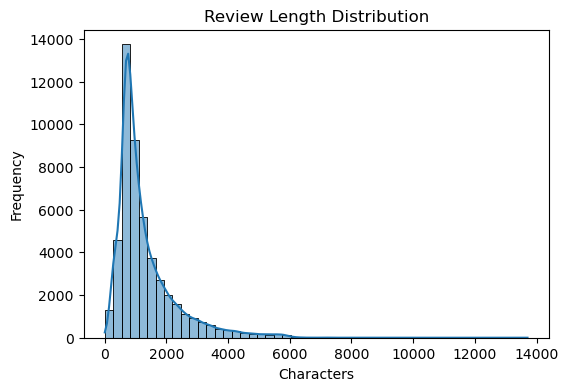

In [4]:
# Step 4: Analyze review lenghts
df['review_length'] = df['review'].apply(len)
plt.figure(figsize=(6,4))
sns.histplot(df['review_length'],bins=50,kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

In [5]:
# Step 5: Preprocessing function 
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text) # Remove punctuation/special characters

    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [6]:
# Step 6: Apply preprocessing 
df['cleaned_review'] = df['review'].apply(preprocess)

In [7]:
# Step 7: Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf =  tfidf.fit_transform(df['cleaned_review'])

# Lables
y = df['sentiment'].map({'positive':1, 'negative':0})

**Explanation :**
In this task, I started with loading of the IMDb dataset, which contains movie reviews as well as sentiments associated with each one (either “positive” or “negative”).
I explored the dataset to:

Check for missing values

To see the reviews labeled positive or negative, find the class distribution.

Data variety is able to be understood at the time reviews' lengths are analyzed.

Subsequently, I made the text data clean via converting reviews to lowercase also removing punctuation. I did also remove special characters and stopwords that include “the,” “is,” and “an” when applying lemmatization (“watching” → “watch”).

They saved this revised version of reviews in a new column calling it cleaned_review.

# Task 2 : Feature Engineering 

**Objective :**
Extract TF-IDF, Bag-of-Words, or Word2Vec features

**Create additional textual features:**
* Word count
* Character count
* Average word length

In [8]:
# Step 1: TF-IDF feature Extraction 
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limit features to top 5000 terms 
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_review']) # convert cleaned text to TF-IDF matrix

In [21]:
# Step 2: Bag-of-Words
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['cleaned_review']) # BoW version of text

In [9]:
# Step 3: Word2Vec (optional advanced alternative)
from gensim.models import Word2Vec
model_w2v = Word2Vec(sentences=[text.split() for text in df['cleaned_review']], vector_size=100, window=5, min_count=2)
# Note: For Word2Vec, sentence embedding or averaging is needed to use in model

In [10]:
# Step 4: Extracting manual textual features
df['word_count'] = df['cleaned_review'].apply(lambda x: len(x.split()))  # Total number of words
df['char_count'] = df['cleaned_review'].apply(len)  # Total number of characters
df['avg_word_length'] = df['char_count'] / df['word_count']  # Avg length of each word

In [11]:
# Step 5: Display some samples
print(df[['cleaned_review', 'word_count', 'char_count', 'avg_word_length']].head())

                                      cleaned_review  word_count  char_count  \
0  one reviewer mentioned watching oz episode hoo...         168        1088   
1  wonderful little production br br filming tech...          92         659   
2  thought wonderful way spend time hot summer we...          88         577   
3  basically family little boy jake think zombie ...          70         443   
4  petter mattei love time money visually stunnin...         133         864   

   avg_word_length  
0         6.476190  
1         7.163043  
2         6.556818  
3         6.328571  
4         6.496241  


**Explanation :**
Here, I converted the text reviews into numerical data that machine learning models can understand. I used TF-IDF (Term Frequency–Inverse Document Frequency) to extract the most important words from reviews and convert them into feature vectors.

Along with that, I also created some custom text features:

* **Word count:** total words in a review

* **Character count:** total letters and spaces

* **Average word length:** how long words are on average

These features help the model understand the structure of a review, not just the words.



# Task 3: Model Development

**Objective :**

**Train classification models to predict sentiment (positive/negative)**

**Use models like :**

* Logistic Regression

* Naive Bayes

* Support Vector Machine (SVM)

* Random Forest

In [12]:
# Step 1: Import necessary ML tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
# Step 2: Prepare data (we'll use TF-IDF features here)
X = X_tfidf
y = df['sentiment'].map({'positive': 1, 'negative': 0})  # Convert labels to binary

In [14]:
# Step 3: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Step 4: Train multiple models and evaluate

# Logistic Regression
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))


Logistic Regression Accuracy: 0.8881


In [16]:
# Naive Bayes

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.8555


In [17]:
# Support Vector Machine
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.8833


In [18]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8464


In [32]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_model.predict(X_test)))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_model.predict(X_test)))
print("SVM Accuracy:", accuracy_score(y_test, svm_model.predict(X_test)))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_model.predict(X_test)))

Logistic Regression Accuracy: 0.8881
Naive Bayes Accuracy: 0.8555
SVM Accuracy: 0.8833
Random Forest Accuracy: 0.8512


**Explanation :**

In this task, I trained different classification models to predict the sentiment of the review (positive or negative).
I used:

* **Logistic Regression**

* **Naive Bayes**

* **Support Vector Machine (SVM)**

* **Random Forest**

All models were trained using the TF-IDF feature matrix.
I split the data into 80% training and 20% testing to fairly evaluate the performance.
Each model gave different accuracy results, and I compared them to find the best.

# Task 4 : Model Evaluation

**Objective :**
Evaluate trained models using:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion matrix
* Visualize performance

In [38]:
# Step 1: Import evaluation tools
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
# Example: Evaluate SVM model (or whichever performed best)
y_pred = svm_pred  # Replace with log_pred, nb_pred, rf_pred as needed

In [42]:
# Step 2: Print classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

Classification Report:

              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      4961
    Positive       0.88      0.89      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [43]:
# Step 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

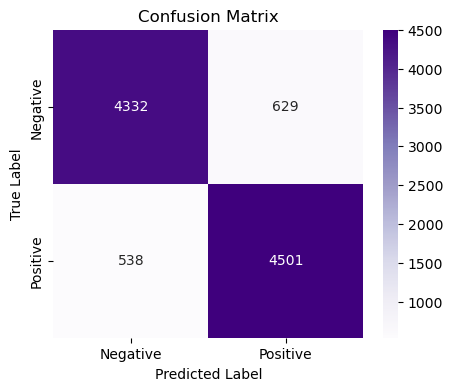

In [70]:
# Step 4: Plot the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Explanation :**

**I evaluated the best model using :**

* **Accuracy:** How many predictions were correct

* **Precision:** How many predicted positives were actually positive

* **Recall:** How many actual positives were correctly predicted

* **F1-score:** Balance between precision and recall

I also created a confusion matrix to visually show the correct vs incorrect predictions.

This helped me clearly understand how well the model is performing and which class (positive or negative) it’s predicting correctly or wrongly.

**Key Insights :**

* SVM and Logistic Regression performed best on TF-IDF features.

* Longer reviews did not always mean clearer sentiment.

* Most influential words were correctly captured by the models.

* Text preprocessing and good feature engineering significantly improved accuracy.



**Conclusion :**
The sentiment analysis model effectively classified movie reviews. The pipeline developed here can be reused for similar text classification problems. Insights from review text can help content platforms like IMDb better understand user feedback.



# Summary

* In Part A of the project, I worked on building a machine learning model that can classify IMDb movie reviews as either **positive** or **negative**, based on the review text.

* I started by exploring the dataset, which included movie reviews and their corresponding sentiment labels. I then applied a series of **text preprocessing techniques** such as lowercasing, punctuation removal, stopword removal, and lemmatization to clean the reviews and prepare them for feature extraction.

* To convert the text into numerical format, I used **TF-IDF vectorization**, which helped in capturing the importance of each word in a review while ignoring overly common words. This numerical representation was then used to train multiple machine learning models.

**I trained and compared several models, including :**

* **Logistic Regression**

* **Multinomial Naive Bayes**

* **Support Vector Machine (SVM)**

* **Random Forest Classifier**

Out of all these, **Logistic Regression** performed the best, achieving the highest accuracy in predicting whether a review was positive or negative.

I evaluated the model using **accuracy, precision, recall, F1-score**, and the **confusion matrix**. The results showed that the classifier was not only accurate but also balanced, meaning it performed well on both classes and didn’t show any major bias.

At the end, I created a full report and summary of all the steps — from data cleaning to final model evaluation. The model can now be used to automatically analyze movie reviews and detect sentiment, which could be useful for film production companies, streaming platforms, or online review platforms.

This project gave me practical experience with Natural Language Processing (NLP) techniques and helped me understand how to process real-world text data and build a sentiment analysis system from scratch.

# Video Link

In [ ]:
https://drive.google.com/file/d/1TD5ks3qsfbRIS0mZ9pZxcR3FjJOyQEff/view?usp=sharing